# 02 — Conhecendo Tiger / Elephant (MIL tabular)

Diferente do MNIST-bags, **estes datasets NÃO são imagens**. Cada imagem já foi segmentada e cada região virou um **vetor de 230 features**. Então:

- não dá pra mostrar a "foto" — só os vetores;
- **não há `instance_labels`** (não sabemos qual região é o animal);
- usamos o `MLPEncoder` (não o `CNNEncoder`).

"Visualizar uma bag" aqui = olhar a **matriz `(n_instâncias × 230)`**: heatmap, perfis de instância e uma projeção PCA.

In [1]:
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from hopmil.data import ClassicMIL

DATASET = 'elephant'   # troque por 'tiger' ou 'fox'
ds = ClassicMIL(DATASET, root='../data/raw/mil')   # baixa na 1a vez
print('dataset:', ds.name)

dataset: elephant


## Parte 1 — Ver o conjunto

In [2]:
labels = [int(b.label) for b in ds.bags]
sizes = [b.instances.shape[0] for b in ds.bags]
feat_dim = ds.bags[0].instances.shape[1]
print(f'n bags        : {len(ds)}  (+{sum(labels)} / -{len(labels)-sum(labels)})')
print(f'n instancias  : {sum(sizes)}')
print(f'features/inst : {feat_dim}')
print(f'tam. de bag   : min={min(sizes)}  mediana={int(np.median(sizes))}  max={max(sizes)}')
print(f'instance_labels disponivel? -> {ds.bags[0].instance_labels is not None}  (None = sem rotulo por instancia)')

n bags        : 200  (+100 / -100)
n instancias  : 1391
features/inst : 230
tam. de bag   : min=2  mediana=7  max=13
instance_labels disponivel? -> False  (None = sem rotulo por instancia)


### Anatomia de UMA bag
Pegamos uma bag positiva. Note os shapes: `instances` é `(n, 230)` — `n` regiões, cada uma um vetor de 230 features.

In [3]:
bag = next(b for b in ds.bags if int(b.label) == 1)
print('bag.instances       ->', tuple(bag.instances.shape), ' (n_regioes, 230 features)')
print('bag.label           ->', bag.label.item(), '(1 = contem o animal)')
print('bag.instance_labels ->', bag.instance_labels)
print()
print('primeira instancia (10 primeiras features):')
print(bag.instances[0, :10])

bag.instances       -> (7, 230)  (n_regioes, 230 features)
bag.label           -> 1 (1 = contem o animal)
bag.instance_labels -> None

primeira instancia (10 primeiras features):
tensor([ 2.1483,  1.6511,  0.0411,  0.0473,  1.4302, -0.6849,  0.1324, -0.0154,
         1.2581, -0.7511])


### Visualização A — a bag como matriz de features (heatmap)
Cada **linha** é uma instância (região); cada **coluna**, uma das 230 features (z-score).

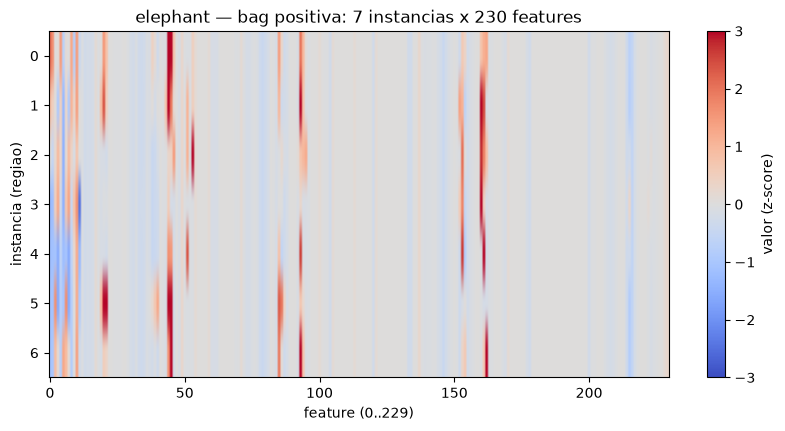

In [4]:
M = bag.instances.numpy()
fig, ax = plt.subplots(figsize=(10, 0.5 * M.shape[0] + 1))
im = ax.imshow(M, aspect='auto', cmap='coolwarm', vmin=-3, vmax=3)
ax.set_xlabel('feature (0..229)'); ax.set_ylabel('instancia (regiao)')
ax.set_yticks(range(M.shape[0]))
ax.set_title(f'{ds.name} — bag positiva: {M.shape[0]} instancias x {M.shape[1]} features')
fig.colorbar(im, ax=ax, label='valor (z-score)')
plt.show()

### Visualização B — perfis de instância
Cada linha mostra o vetor de 230 features de uma instância. Instâncias diferentes = regiões diferentes da imagem.

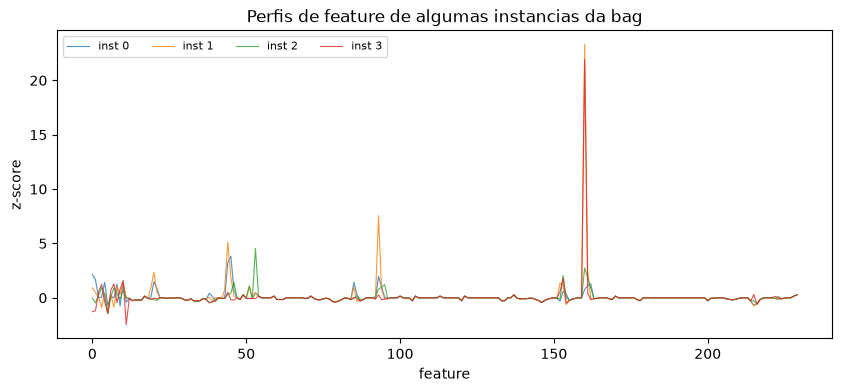

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(min(4, M.shape[0])):
    ax.plot(M[i], lw=0.8, alpha=0.8, label=f'inst {i}')
ax.set_xlabel('feature'); ax.set_ylabel('z-score'); ax.legend(ncol=4, fontsize=8)
ax.set_title('Perfis de feature de algumas instancias da bag')
plt.show()

### Visualização C — PCA: as instâncias da bag no espaço de features
Projetamos TODAS as instâncias do dataset em 2D (cinza) e destacamos as da nossa bag (vermelho). Mostra onde as regiões dessa imagem caem no espaço.

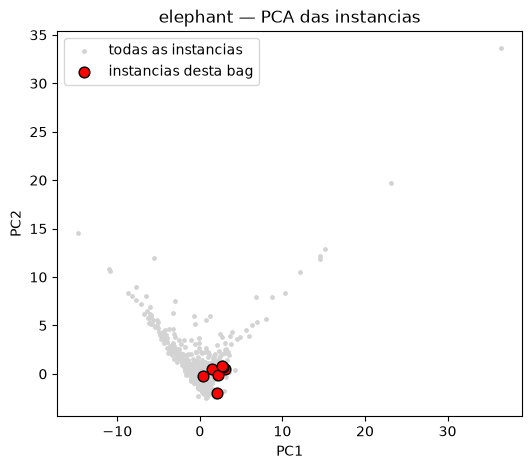

In [6]:
allX = torch.cat([b.instances for b in ds.bags]).numpy()
p2 = PCA(n_components=2).fit(allX)
A = p2.transform(allX)
B = p2.transform(M)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(A[:, 0], A[:, 1], s=6, c='lightgray', label='todas as instancias')
ax.scatter(B[:, 0], B[:, 1], s=60, c='red', edgecolor='k', label='instancias desta bag')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend()
ax.set_title(f'{ds.name} — PCA das instancias')
plt.show()

## Parte 2 — A MESMA pipeline, agora com `MLPEncoder`
O fluxo é idêntico ao do MNIST-bags; só muda o encoder (tabular → MLP) e `in_dim=230`.

In [7]:
from hopmil.models import MLPEncoder, build_aggregator, MILClassifier

DIM = 128
encoder = MLPEncoder(in_dim=230, dim=DIM)
aggregator = build_aggregator('attention', dim=DIM)
clf = MILClassifier(encoder, aggregator, num_classes=1, dim=DIM).eval()

with torch.no_grad():
    x = bag.instances
    print('1) entrada        :', tuple(x.shape))
    emb = encoder(x);  print('2) apos encoder   :', tuple(emb.shape))
    z, w = aggregator(emb); print('3) vetor da bag   :', tuple(z.shape), '| weights', tuple(w.shape))
    prob = torch.sigmoid(clf.head(z))
    print('4) probabilidade  :', round(prob.item(), 3), '(rede sem treino)')

1) entrada        : (7, 230)
2) apos encoder   : (7, 128)
3) vetor da bag   : (128,) | weights (7,)
4) probabilidade  : 0.527 (rede sem treino)


## Resumo

- Tiger/Elephant/Fox são **bags de vetores de 230 features**, sem imagem e sem rótulo por instância.
- Por isso: encoder = `MLPEncoder`, e a métrica de localização por instância **não se aplica** (só MNIST-bags tem `instance_labels`).
- A pipeline `encoder → agregador → head` é a mesma — é exatamente isso que permite comparar os 4 agregadores nos mesmos dados.